# Predicción de lluvia en Australia mediante análisis de datos y aprendizaje automático

## Aplicación de la metodología CRISP-DM sobre datos meteorológicos históricos (2008–2017)

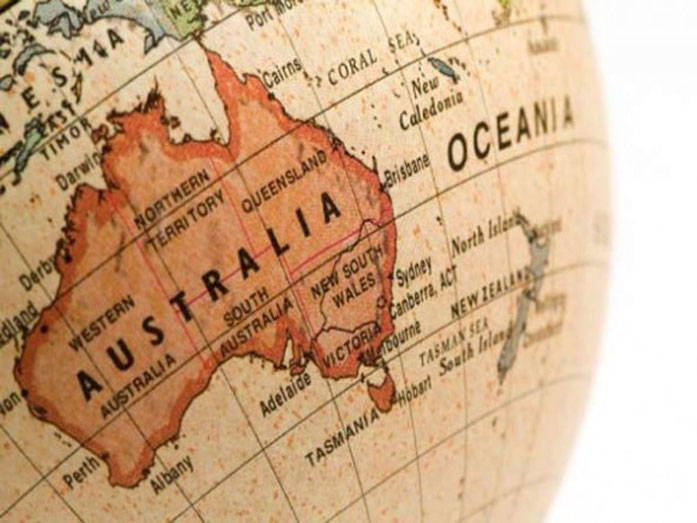

# 1- Business Understanding (Comprensión del negocio)

## Contexto

Australia presenta una gran diversidad climática debido a su extensión geográfica, con regiones que van desde zonas tropicales hasta áreas áridas y templadas. Esta diversidad permite estudiar cómo distintas condiciones meteorológicas se relacionan con la ocurrencia de precipitaciones en diferentes ubicaciones del país.

El presente proyecto utiliza registros meteorológicos diarios de distintas estaciones de Australia correspondientes al período 2008–2017. Los datos contienen información relacionada con temperatura, humedad, presión atmosférica, precipitaciones, nubosidad y condiciones del viento, entre otras variables.

## Problema

La ocurrencia de lluvia puede estar asociada a múltiples condiciones meteorológicas y su comportamiento puede variar según la ubicación. Por ello, resulta relevante determinar si las condiciones meteorológicas observadas durante un día contienen información suficiente para anticipar la ocurrencia de lluvia al día siguiente.

A partir de este problema, se busca analizar los principales patrones meteorológicos asociados a la lluvia y evaluar si estos pueden utilizarse para construir modelos capaces de predecir su ocurrencia.

## Objetivo

El objetivo principal del proyecto es analizar los factores meteorológicos asociados a la ocurrencia de lluvia y evaluar la capacidad de distintos modelos de clasificación para predecir si lloverá al día siguiente (`RainTomorrow`), utilizando únicamente información meteorológica disponible durante el día actual.

## Preguntas de investigación

Para alcanzar este objetivo, se plantean las siguientes preguntas:

* ¿Qué variables meteorológicas presentan una mayor relación con la ocurrencia de lluvia al día siguiente?
* ¿Cómo varía la ocurrencia de lluvia entre las distintas ubicaciones de Australia y qué diferencias meteorológicas caracterizan a estas regiones?
* ¿Qué tan bien es posible predecir la ocurrencia de lluvia al día siguiente utilizando las condiciones meteorológicas observadas durante el día actual?
* ¿Qué modelo de clasificación presenta el mejor desempeño para este problema y qué variables tienen mayor importancia en sus predicciones?

## Criterios de éxito

El proyecto será considerado exitoso si permite identificar patrones meteorológicos relevantes asociados a la ocurrencia de lluvia y evaluar de manera objetiva la capacidad de distintos modelos para predecir `RainTomorrow`.

La evaluación de los modelos no se basará únicamente en la exactitud (`accuracy`), sino que se considerarán métricas como precisión (`precision`), sensibilidad (`recall`), puntuación F1 (`F1-score`) y matriz de confusión. Estas métricas permitirán evaluar de manera más completa la capacidad de los modelos para identificar correctamente tanto los días con lluvia como los días sin lluvia.

La selección del modelo final se realizará considerando su desempeño global y las características del problema, teniendo en cuenta especialmente la distribución de las clases y la capacidad del modelo para detectar correctamente los casos de lluvia.

## Alcance

El análisis se realizará utilizando los registros meteorológicos disponibles en el conjunto de datos `weatherAUS`, considerando las distintas ubicaciones incluidas en el dataset y las variables meteorológicas disponibles para cada observación.

Para la etapa de modelamiento, `RainTomorrow` será utilizada como variable objetivo. Se utilizarán únicamente variables que representen información disponible durante el día en que se realiza la predicción. Las variables que contengan información correspondiente al día siguiente serán excluidas del modelamiento para evitar problemas de *data leakage*.

El proyecto se enfocará en el análisis de datos y la evaluación de modelos de clasificación sobre información meteorológica histórica. Por lo tanto, los resultados obtenidos no deben interpretarse como un sistema meteorológico operacional ni como un mecanismo de predicción en tiempo real.

## Resultado esperado

Se espera identificar los principales patrones y variables meteorológicas asociados a la ocurrencia de lluvia en Australia, así como determinar si estas condiciones permiten anticipar la lluvia del día siguiente.

Además, se espera comparar distintos modelos de clasificación, analizar sus fortalezas y limitaciones e identificar las variables que presentan mayor importancia en sus predicciones.

De esta manera, el proyecto permitirá aplicar las principales etapas de la metodología CRISP-DM, desde la definición del problema y la comprensión de los datos hasta la preparación, modelamiento, evaluación e interpretación de los resultados.

# 2- Data Understanding (Comprensión de datos)

La etapa de *Data Understanding* tiene como objetivo conocer y comprender el conjunto de datos antes de realizar cualquier transformación o preparación para el modelamiento.

Para ello, se desarrollarán las siguientes actividades:

* **Recolección inicial de los datos:** identificar el origen del conjunto de datos y cargarlo para su posterior análisis.
* **Descripción de los datos:** examinar la estructura, dimensiones, tipos de variables y características generales del conjunto de datos.
* **Exploración de los datos:** analizar la distribución de las variables, identificar patrones iniciales y estudiar las relaciones entre las variables relevantes para el problema.
* **Verificación de la calidad de los datos:** identificar valores faltantes, posibles inconsistencias, valores atípicos y otros problemas que puedan afectar las etapas posteriores del proyecto.

## 2.1 Recolección inicial de los datos

In [1]:
import pandas as pd
from google.colab import drive

# 1. Montar Google Drive en el entorno de Colab
drive.mount('/content/drive')

# 2. Ruta exacta al archivo dentro de tu Drive
file_path = (
    '/content/drive/MyDrive/Colab'
    ' Notebooks/WeatherAUS_CRISP_DM/weatherAUS.csv'
)

# 3. Lectura directa
df = pd.read_csv(file_path)

print(
    f"Dataset cargado exitosamente desde Google Drive: {df.shape[0]:,} filas y"
    f" {df.shape[1]} columnas."
)


Mounted at /content/drive
Dataset cargado exitosamente desde Google Drive: 142,193 filas y 24 columnas.


## 2.2 Descripción de los datos

In [2]:
# Clasificación de variables y recuento de valores únicos
var_summary = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores Únicos': df.nunique(),
    'Valores No Nulos': df.count(),
    'Primer Registro': df.iloc[0]
})

print(f"Total variables numéricas: {df.select_dtypes(include=['float64', 'int64']).shape[1]}")
print(f"Total variables categóricas/objeto: {df.select_dtypes(include=['object']).shape[1]}")

var_summary

Total variables numéricas: 17
Total variables categóricas/objeto: 7


,Tipo,Valores Únicos,Valores No Nulos,Primer Registro
Date,object,3436,142193,2008-12-01
Location,object,49,142193,Albury
MinTemp,float64,389,141556,13.4
MaxTemp,float64,505,141871,22.9
Rainfall,float64,679,140787,0.6
Evaporation,float64,356,81350,NaN
Sunshine,float64,145,74377,NaN
WindGustDir,object,16,132863,W
WindGustSpeed,float64,67,132923,44.0
WindDir9am,object,16,132180,W


### Resumen Estadístico Inicial

In [3]:
# Estadísticas descriptivas de variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,141556.0,12.186400,6.403283,-8.5,7.6,12.0,16.8,33.9
MaxTemp,141871.0,23.226784,7.117618,-4.8,17.9,22.6,28.2,48.1
Rainfall,140787.0,2.349974,8.465173,0.0,0.0,0.0,0.8,371.0
Evaporation,81350.0,5.469824,4.188537,0.0,2.6,4.8,7.4,145.0
Sunshine,74377.0,7.624853,3.781525,0.0,4.9,8.5,10.6,14.5
WindGustSpeed,132923.0,39.984292,13.588801,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,140845.0,14.001988,8.893337,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,139563.0,18.637576,8.803345,0.0,13.0,19.0,24.0,87.0
Humidity9am,140419.0,68.843810,19.051293,0.0,57.0,70.0,83.0,100.0
Humidity3pm,138583.0,51.482606,20.797772,0.0,37.0,52.0,66.0,100.0


In [4]:
# Resumen de variables categóricas
df.describe(include=['O']).T

,count,unique,top,freq
Date,142193,3436,2017-06-23,49
Location,142193,49,Canberra,3418
WindGustDir,132863,16,W,9780
WindDir9am,132180,16,N,11393
WindDir3pm,138415,16,SE,10663
RainToday,140787,2,No,109332
RainTomorrow,142193,2,No,110316


## 2.3 Verificación de la Calidad de los Datos (Data Quality)

In [5]:
# 1. Duplicados exactos
duplicados = df.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicados}")

# 2. Diagnóstico de valores nulos por columna
missing = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values(by='Porcentaje (%)', ascending=False)

# Mostrar solo las columnas que tienen datos faltantes
missing[missing['Nulos'] > 0]

Filas duplicadas exactas: 0


,Nulos,Porcentaje (%)
Sunshine,67816,47.69
Evaporation,60843,42.79
Cloud3pm,57094,40.15
Cloud9am,53657,37.74
Pressure9am,14014,9.86
Pressure3pm,13981,9.83
WindDir9am,10013,7.04
WindGustDir,9330,6.56
WindGustSpeed,9270,6.52
WindDir3pm,3778,2.66


In [6]:
# Conteo absoluto y porcentual de RainTomorrow (incluyendo valores nulos)
target_audit = pd.DataFrame({
    'Total': df['RainTomorrow'].value_counts(dropna=False),
    'Proporción (%)': (df['RainTomorrow'].value_counts(dropna=False, normalize=True) * 100).round(2)
})

target_audit

,Total,Proporción (%)
RainTomorrow,,
No,110316,77.58
Yes,31877,22.42


#### Conclusiones de Calidad de Datos
- **Duplicados:** No existen filas duplicadas en el conjunto de datos.
- **Variables con alta pérdida:** `Sunshine` (47.69%), `Evaporation` (42.79%), `Cloud3pm` (40.15%) y `Cloud9am` (37.74%) superan el 35% de datos faltantes, lo que requerirá evaluar su descarte o imputación estratégica en la etapa de Data Preparation.
- **Variables con baja pérdida:** Variables dinámicas como presión, velocidad del viento y humedad presentan menos del 10% de valores ausentes.
- **Variable objetivo:** Los registros con `RainTomorrow` nulo representan instancias sin etiqueta válida que deberán ser removidas durante la preparación para evitar sesgo.

## 2.4 Exploración de los Datos (EDA)
Análisis de la distribución de clases, comportamiento temporal y relación entre variables meteorológicas clave.

### Balance de la Variable Objetivo

/tmp/ipykernel_1947/3757229001.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df.dropna(subset=['RainTomorrow']), x='RainTomorrow', palette=['#34495e', '#3498db'])


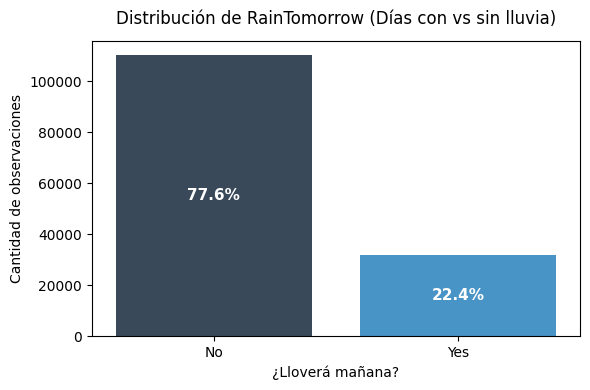

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización del desbalance de la variable objetivo
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df.dropna(subset=['RainTomorrow']), x='RainTomorrow', palette=['#34495e', '#3498db'])

plt.title('Distribución de RainTomorrow (Días con vs sin lluvia)', fontsize=12, pad=12)
plt.xlabel('¿Lloverá mañana?', fontsize=10)
plt.ylabel('Cantidad de observaciones', fontsize=10)

# Etiquetas con porcentaje sobre cada barra
total = len(df.dropna(subset=['RainTomorrow']))
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### Análisis de Correlación y Multicolinealidad

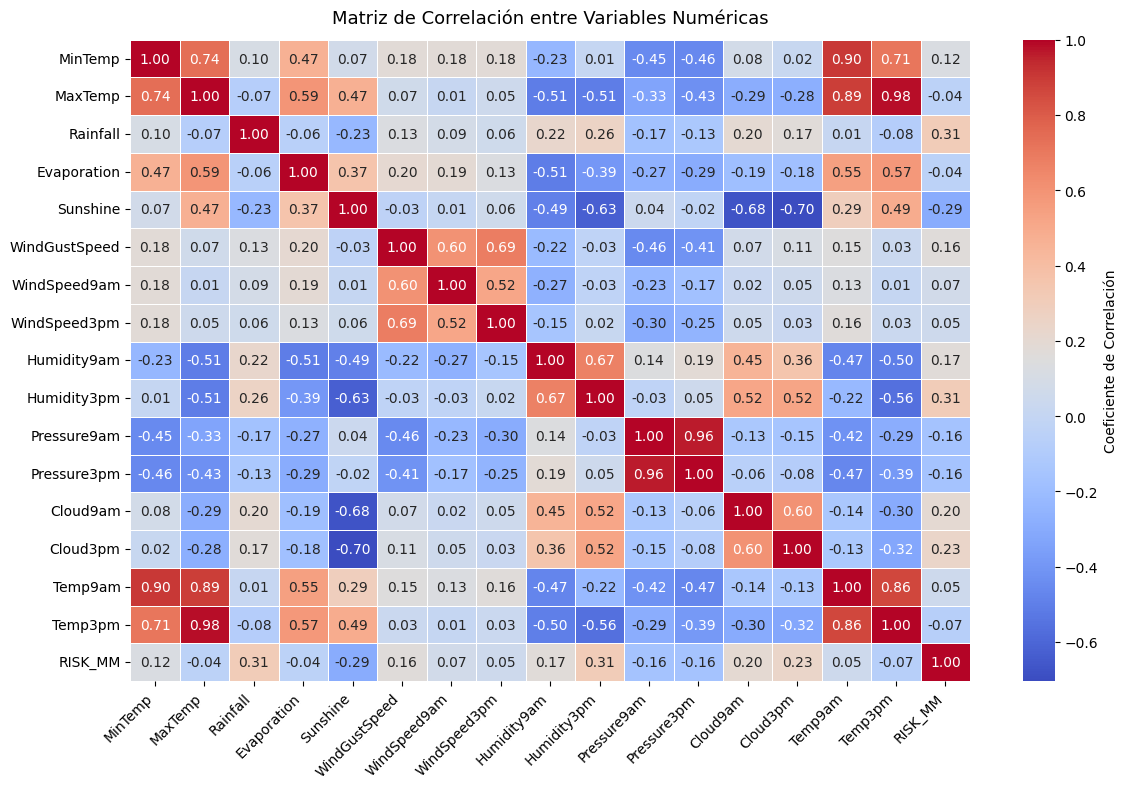

In [8]:
# Selección de variables numéricas
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Cálculo de la matriz de correlación (Pearson)
corr_matrix = df[numeric_cols].corr()

# Visualización mediante mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación'},
)
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Comportamiento de Factores Clave (Humedad y Presión)

/tmp/ipykernel_1947/718282307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1947/718282307.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


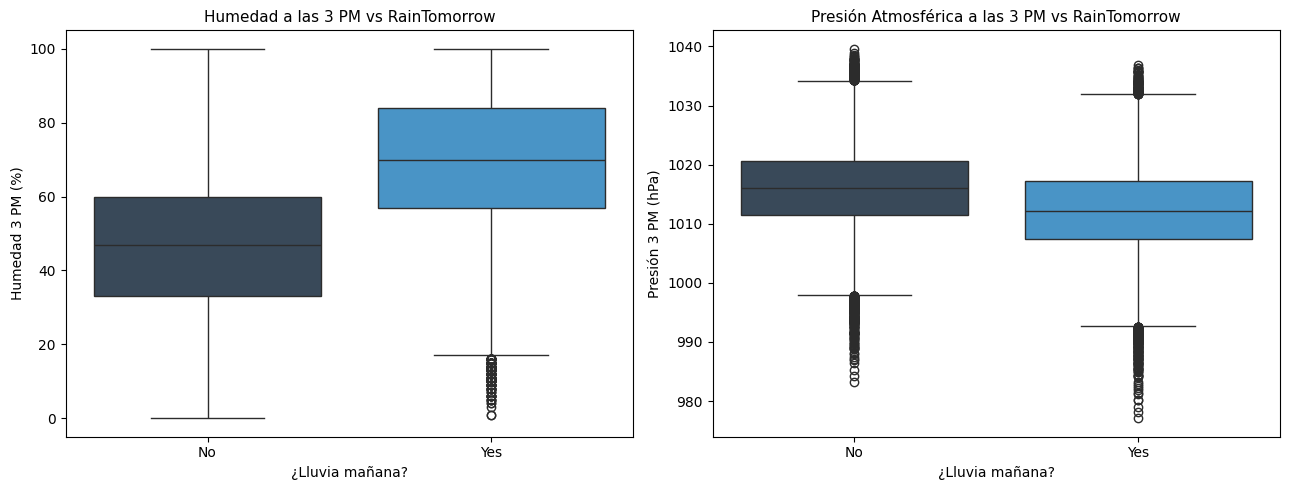

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución de Humedad a las 3pm según RainTomorrow
sns.boxplot(
    data=df,
    x='RainTomorrow',
    y='Humidity3pm',
    palette=['#34495e', '#3498db'],
    ax=axes[0],
)
axes[0].set_title('Humedad a las 3 PM vs RainTomorrow', fontsize=11)
axes[0].set_xlabel('¿Lluvia mañana?')
axes[0].set_ylabel('Humedad 3 PM (%)')

# Distribución de Presión a las 3pm según RainTomorrow
sns.boxplot(
    data=df,
    x='RainTomorrow',
    y='Pressure3pm',
    palette=['#34495e', '#3498db'],
    ax=axes[1],
)
axes[1].set_title('Presión Atmosférica a las 3 PM vs RainTomorrow', fontsize=11)
axes[1].set_xlabel('¿Lluvia mañana?')
axes[1].set_ylabel('Presión 3 PM (hPa)')

plt.tight_layout()
plt.show()

### Variabilidad Geográfica de las Precipitaciones

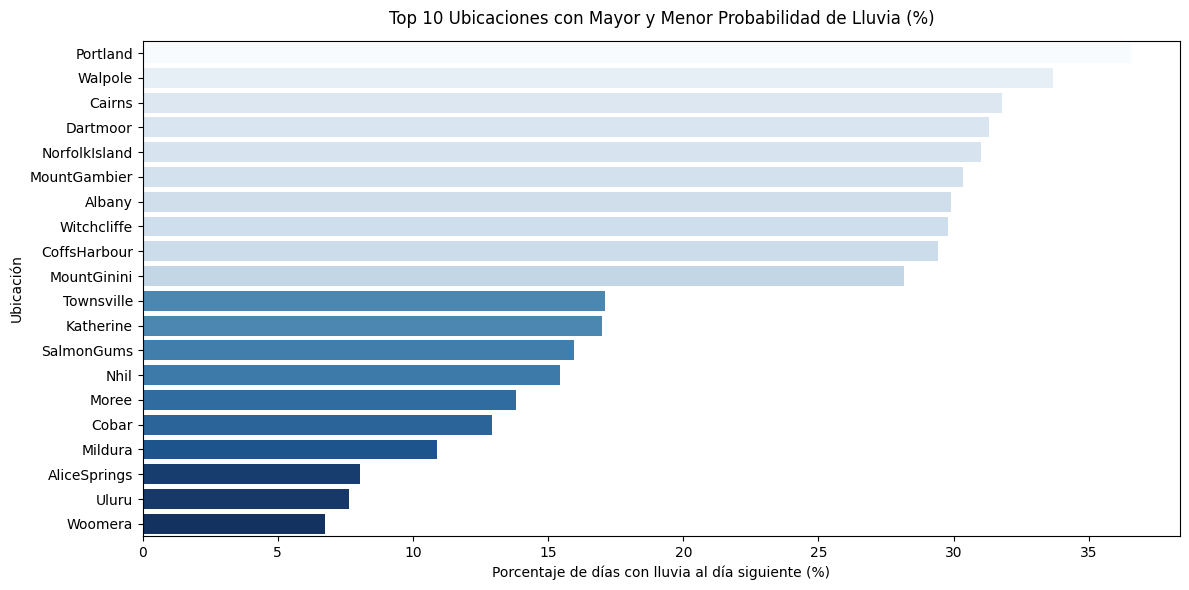

In [10]:
# Cálculo de la proporción de días lluviosos por ciudad/estación
location_rain = (
    df.groupby('Location')['RainTomorrow']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .sort_values(by='RainTomorrow', ascending=False)
)

# Visualización de las 10 ubicaciones más y 10 menos lluviosas
top_bottom_loc = pd.concat([location_rain.head(10), location_rain.tail(10)])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_bottom_loc,
    x='RainTomorrow',
    y='Location',
    hue='RainTomorrow',
    palette='Blues_r',
    legend=False,
)
plt.title(
    'Top 10 Ubicaciones con Mayor y Menor Probabilidad de Lluvia (%)',
    fontsize=12,
    pad=12,
)
plt.xlabel('Porcentaje de días con lluvia al día siguiente (%)', fontsize=10)
plt.ylabel('Ubicación', fontsize=10)
plt.tight_layout()
plt.show()

### Análisis Temporal y Estacionalidad

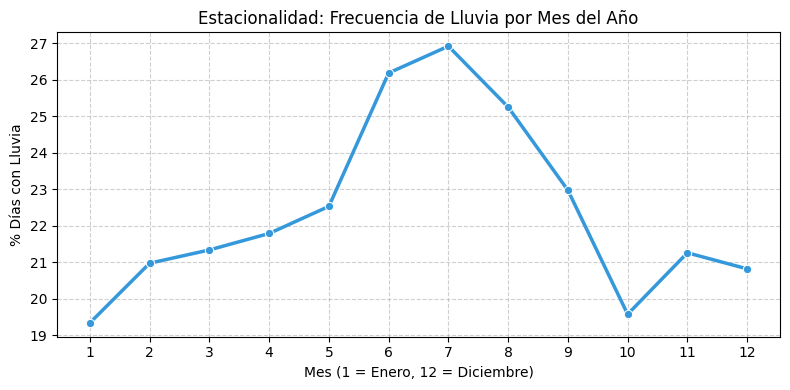

In [11]:
# Extracción temporal para análisis de estacionalidad
df_temp = df[['Date', 'RainTomorrow']].dropna().copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'])
df_temp['Month'] = df_temp['Date'].dt.month
df_temp['RainTomorrow_Num'] = df_temp['RainTomorrow'].map({'Yes': 1, 'No': 0})

# Frecuencia de lluvia promedio por mes calendario
monthly_rain = (
    df_temp.groupby('Month')['RainTomorrow_Num'].mean() * 100
).reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=monthly_rain,
    x='Month',
    y='RainTomorrow_Num',
    marker='o',
    color='#3498db',
    linewidth=2.5,
)
plt.title('Estacionalidad: Frecuencia de Lluvia por Mes del Año', fontsize=12)
plt.xlabel('Mes (1 = Enero, 12 = Diciembre)', fontsize=10)
plt.ylabel('% Días con Lluvia', fontsize=10)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2.5 Síntesis de Data Understanding
1. **Desbalance de Clases:** ~78% días sin lluvia (`No`) frente a ~22% días con lluvia (`Yes`). Las métricas de corte como Recall y F1-Score serán prioritarias.
2. **Data Leakage Identificado:** La variable `RISK_MM` contiene información del volumen de lluvia del día siguiente, por lo que debe ser eliminada antes del entrenamiento.
3. **Pérdida Crítica de Datos:** `Sunshine`, `Evaporation`, `Cloud3pm` y `Cloud9am` presentan entre 37% y 48% de nulos, lo que requiere una decisión de ingeniería (imputar vs. descartar).
4. **Separación de Variables:** `Humidity3pm` (humedad de la tarde) y `Pressure3pm` (presión atmosférica) son los indicadores individuales con mayor diferenciación visual respecto a si lloverá o no.
5. **Variabilidad Espacio-Temporal:** La probabilidad de lluvia varía fuertemente según la estación del año (pico en invierno: junio-julio) y la región geográfica (costa húmeda vs. interior árido).

# 3- Data Preparation (Preparación de los Datos)

En esta fase se procesa el dataset para dejarlo en condiciones óptimas para el modelamiento predictivo:
1. **Prevención de Data Leakage:** Eliminación de la columna `RISK_MM`.
2. **Filtrado del Target:** Remoción de filas donde `RainTomorrow` es nulo.
3. **Ingeniería de Características Temporales:** Extracción del mes a partir de `Date`.
4. **Manejo de Columnas con Pérdida Crítica:** Descarte de variables con más de 35% de valores ausentes (`Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am`).
5. **Separación de Matrices:** Definición de $X$ (features) e $y$ (target).
6. **División Train / Test Split:** Partición estratificada previa a la imputación para evitar fuga de datos (*data leakage* metodológico).

In [12]:
# 1. Copia de trabajo
df_prep = df.copy()

# 2. Eliminación de columna causante de Data Leakage
if 'RISK_MM' in df_prep.columns:
    df_prep = df_prep.drop(columns=['RISK_MM'])
    print("✓ Columna RISK_MM eliminada con éxito.")

# 3. Remoción de registros sin etiqueta objetivo
df_prep = df_prep.dropna(subset=['RainTomorrow'])
print(f"✓ Registros restantes tras depurar el target: {df_prep.shape[0]:,}")

# 4. Descarte de columnas con >35% de nulos detectadas en el EDA
high_null_cols = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
df_prep = df_prep.drop(columns=high_null_cols)
print(f"✓ Columnas con alta tasa de nulos descartadas: {high_null_cols}")

# 5. Ingeniería de la variable temporal
df_prep['Date'] = pd.to_datetime(df_prep['Date'])
df_prep['Month'] = df_prep['Date'].dt.month
df_prep = df_prep.drop(columns=['Date'])
print("✓ Característica 'Month' extraída y columna 'Date' removida.")

# 6. Mapeo binario de variables dicotómicas
df_prep['RainToday'] = df_prep['RainToday'].map({'No': 0, 'Yes': 1})
df_prep['RainTomorrow'] = df_prep['RainTomorrow'].map({'No': 0, 'Yes': 1})

# 7. Separación de features (X) y target (y)
X = df_prep.drop(columns=['RainTomorrow'])
y = df_prep['RainTomorrow']

print(f"\nDimensiones finales de X: {X.shape}")
print(f"Dimensiones finales de y: {y.shape}")

✓ Columna RISK_MM eliminada con éxito.
✓ Registros restantes tras depurar el target: 142,193
✓ Columnas con alta tasa de nulos descartadas: ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
✓ Característica 'Month' extraída y columna 'Date' removida.

Dimensiones finales de X: (142193, 18)
Dimensiones finales de y: (142193,)


## 3.1 Partición de Datos (Train/Test Split)

Se divide el conjunto de datos en un 80% para entrenamiento y 20% para evaluación final independiente. Se utiliza partición estratificada (`stratify=y`) para preservar la proporción de la variable objetivo y mitigar sesgos por desbalance.

In [13]:
from sklearn.model_selection import train_test_split

# Partición 80/20 con estratificación y semilla reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dimensiones X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"Dimensiones X_test:  {X_test.shape} | y_test:  {y_test.shape}")

# Verificación de consistencia en el ratio de clases
print(
    f"\nProporción clase 1 en Train: {y_train.mean():.4f} ({y_train.mean()*100:.2f}%)"
)
print(
    f"Proporción clase 1 en Test:  {y_test.mean():.4f} ({y_test.mean()*100:.2f}%)"
)

Dimensiones X_train: (113754, 18) | y_train: (113754,)
Dimensiones X_test:  (28439, 18) | y_test:  (28439,)

Proporción clase 1 en Train: 0.2242 (22.42%)
Proporción clase 1 en Test:  0.2242 (22.42%)


## 3.2 Transformación e Imputación de Características (ColumnTransformer)

Para tratar los valores nulos restantes y preparar las variables para algoritmos lineales y basados en árboles:
- **Variables numéricas:** Imputación por mediana (robusta a valores atípicos) y estandarización (`StandardScaler`).
- **Variables categóricas:** Imputación por la moda (`most_frequent`) y codificación One-Hot (`OneHotEncoder`, ignorando categorías no vistas con `handle_unknown='ignore'`).

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Identificación automática de tipos de columnas en el set de entrenamiento
num_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas ({len(num_features)}): {num_features}")
print(f"Variables categóricas ({len(cat_features)}): {cat_features}")

# 2. Pipeline numérico: Imputación por mediana + Estandarización
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

# 3. Pipeline categórico: Imputación por moda + OneHotEncoding
cat_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]
)

# 4. Integrador general de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
    ]
)

# 5. Ajuste exclusivo en Train y posterior transformación en Train y Test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(
    f"\n✓ Preprocesamiento exitoso."
    f"\nDimensiones finales de X_train_processed: {X_train_processed.shape}"
    f"\nDimensiones finales de X_test_processed:  {X_test_processed.shape}"
)

Variables numéricas (13): ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday']
Variables categóricas (4): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

✓ Preprocesamiento exitoso.
Dimensiones finales de X_train_processed: (113754, 110)
Dimensiones finales de X_test_processed:  (28439, 110)


# 4- Modeling (Modelamiento)

En esta fase se seleccionan, entrenan y calibran algoritmos de Machine Learning para predecir si lloverá al día siguiente (`RainTomorrow`).

Dado el desbalance de clases (~78% sin lluvia vs. ~22% con lluvia), la métrica principal de optimización no será el Accuracy general, sino el **ROC-AUC** y el **F1-Score / Recall** de la clase positiva (`Yes`).

Se implementará una estrategia comparativa progresiva:
1. **Modelo Base (Baseline):** Regresión Logística con balanceo de pesos de clase (`class_weight='balanced'`).
2. **Modelo Basado en Árboles:** Random Forest Classifier para capturar no-linealidades e interacciones complejas.
3. **Modelo de Boosting:** LightGBM / XGBoost para maximizar rendimiento y velocidad de convergencia.

## 4.1 Modelo Base (Logistic Regression)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 1. Instanciación del modelo baseline lineal con compensación de desbalance
lr_model = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42
)

# 2. Ajuste en el conjunto preprocesado de entrenamiento
lr_model.fit(X_train_processed, y_train)

# 3. Predicciones de probabilidad y clase en Test
y_pred_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]
y_pred_lr = lr_model.predict(X_test_processed)

# 4. Evaluación inicial del baseline
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"=== Baseline: Logistic Regression ===")
print(f"ROC-AUC Score: {roc_auc_lr:.4f}\n")
print(
    classification_report(
        y_test, y_pred_lr, target_names=['No Lluvia (0)', 'Lluvia (1)']
    )
)

=== Baseline: Logistic Regression ===
ROC-AUC Score: 0.8637

               precision    recall  f1-score   support

No Lluvia (0)       0.92      0.79      0.85     22064
   Lluvia (1)       0.52      0.77      0.62      6375

     accuracy                           0.79     28439
    macro avg       0.72      0.78      0.74     28439
 weighted avg       0.83      0.79      0.80     28439



## 4.2 Modelo de Ensamble (Random Forest)

In [16]:
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciación de Random Forest (árboles paralelos)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

# 2. Ajuste
rf_model.fit(X_train_processed, y_train)

# 3. Predicciones
y_pred_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]
y_pred_rf = rf_model.predict(X_test_processed)

# 4. Evaluación
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"=== Modelo Ensamble: Random Forest ===")
print(f"ROC-AUC Score: {roc_auc_rf:.4f}\n")
print(
    classification_report(
        y_test, y_pred_rf, target_names=['No Lluvia (0)', 'Lluvia (1)']
    )
)

=== Modelo Ensamble: Random Forest ===
ROC-AUC Score: 0.8625

               precision    recall  f1-score   support

No Lluvia (0)       0.91      0.82      0.87     22064
   Lluvia (1)       0.54      0.74      0.62      6375

     accuracy                           0.80     28439
    macro avg       0.73      0.78      0.75     28439
 weighted avg       0.83      0.80      0.81     28439



## 4.3 Modelo de Gradient Boosting: LightGBM

Se implementa LightGBM (`LGBMClassifier`) para evaluar si un enfoque de boosting secuencial supera el rendimiento del baseline lineal y del ensamble paralelo. Se configura `scale_pos_weight` para compensar el desbalance de clases (~3.46 a 1 a favor de la clase negativa).

In [17]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# Cálculo del ratio de desbalance: negativas / positivas
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# 1. Instanciación de LightGBM con manejo de desbalance
lgbm_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
)

# 2. Ajuste
lgbm_model.fit(X_train_processed, y_train)

# 3. Predicciones
y_pred_proba_lgb = lgbm_model.predict_proba(X_test_processed)[:, 1]
y_pred_lgb = lgbm_model.predict(X_test_processed)

# 4. Evaluación
roc_auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)

print(f"=== Gradient Boosting: LightGBM ===")
print(f"ROC-AUC Score: {roc_auc_lgb:.4f}\n")
print(
    classification_report(
        y_test, y_pred_lgb, target_names=['No Lluvia (0)', 'Lluvia (1)']
    )
)

[LightGBM] [Info] Number of positive: 25502, number of negative: 88252
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014875 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2328
[LightGBM] [Info] Number of data points in the train set: 113754, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224186 -> initscore=-1.241439
[LightGBM] [Info] Start training from score -1.241439


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Gradient Boosting: LightGBM ===
ROC-AUC Score: 0.8843

               precision    recall  f1-score   support

No Lluvia (0)       0.93      0.81      0.87     22064
   Lluvia (1)       0.55      0.79      0.64      6375

     accuracy                           0.81     28439
    macro avg       0.74      0.80      0.76     28439
 weighted avg       0.84      0.81      0.82     28439



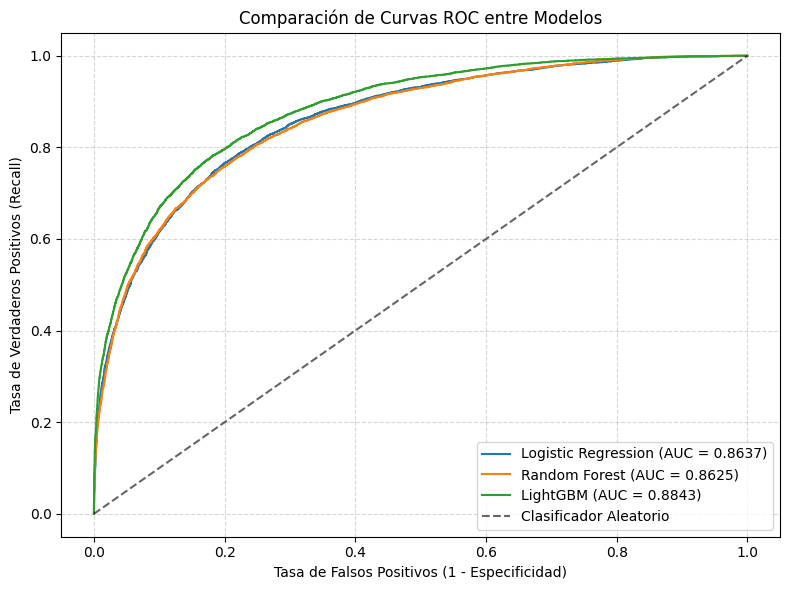

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Cálculo de curvas ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb)

# Gráfico comparativo
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Clasificador Aleatorio')

plt.title('Comparación de Curvas ROC entre Modelos', fontsize=12)
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5- Evaluation (Evaluación del Modelo)

En esta fase se profundiza en el diagnóstico del modelo seleccionado (**LightGBM**) para evaluar su viabilidad operativa:
1. **Matriz de Confusión:** Cuantificación exacta de falsos positivos y falsos negativos.
2. **Feature Importance:** Identificación de las variables meteorológicas con mayor peso predictivo.
3. **Calibración de Umbral de Decisión:** Análisis de impacto entre sensibilidad y precisión según el objetivo del negocio.

## 5.1 Matriz de Confusión Normalizada

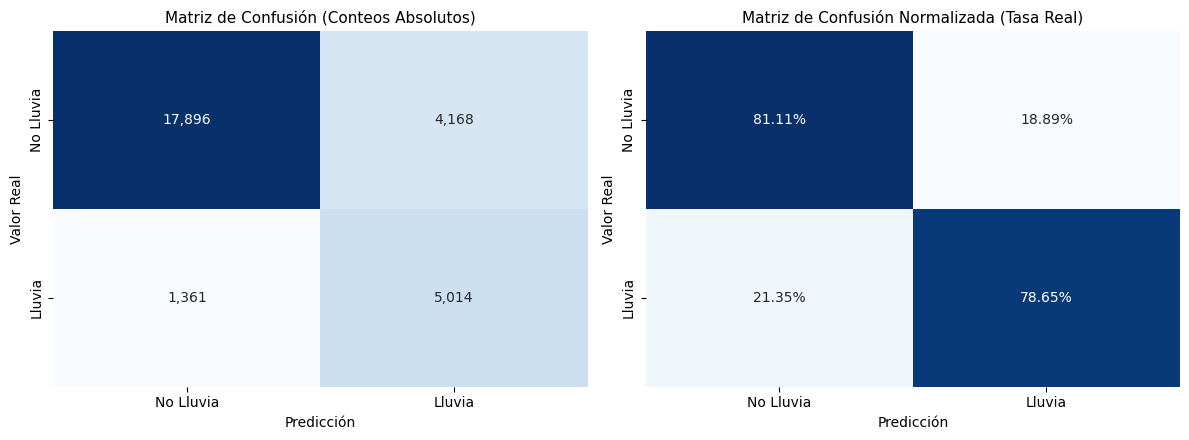

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matriz de confusión absoluta y relativa
cm = confusion_matrix(y_test, y_pred_lgb)
cm_norm = confusion_matrix(y_test, y_pred_lgb, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Conteo absoluto
sns.heatmap(
    cm,
    annot=True,
    fmt=',d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=['No Lluvia', 'Lluvia'],
    yticklabels=['No Lluvia', 'Lluvia'],
)
axes[0].set_title('Matriz de Confusión (Conteos Absolutos)', fontsize=11)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

# Porcentajes normalizados por fila (Recall por clase)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    cbar=False,
    ax=axes[1],
    xticklabels=['No Lluvia', 'Lluvia'],
    yticklabels=['No Lluvia', 'Lluvia'],
)
axes[1].set_title('Matriz de Confusión Normalizada (Tasa Real)', fontsize=11)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

## 5.2 Importancia de Características (Feature Importance)

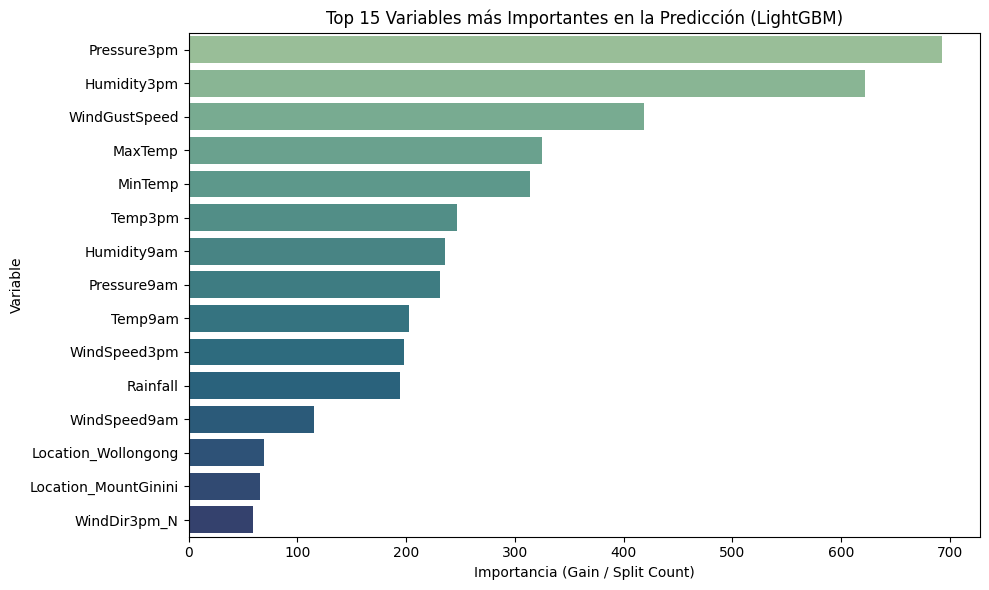

In [20]:
import numpy as np
import pandas as pd

# Recuperar los nombres exactos de las columnas tras el One-Hot Encoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_encoded_cols = cat_encoder.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_encoded_cols

# Extraer importancias del modelo LightGBM
feat_imp = pd.DataFrame(
    {'Feature': all_feature_names, 'Importance': lgbm_model.feature_importances_}
).sort_values(by='Importance', ascending=False)

# Gráfico de las 15 variables más influyentes
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp.head(15),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='crest',
    legend=False,
)
plt.title(
    'Top 15 Variables más Importantes en la Predicción (LightGBM)', fontsize=12
)
plt.xlabel('Importancia (Gain / Split Count)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# 6- Deployment (Despliegue y Puesta en Producción)

En esta fase final de la metodología CRISP-DM se prepara el activo analítico para su integración en entornos operativos:
1. **Empaquetado del Pipeline:** Exportación del transformador (`preprocessor`) y del modelo final calibrado (`lgbm_model`) en un único artefacto serializado.
2. **Función de Inferencia:** Construcción de una interfaz predictiva capaz de recibir datos crudos y generar el pronóstico con su probabilidad asociada.
3. **Simulación de Predicción en Vivo:** Prueba de inferencia con un registro sintético de entrada.

## 6.1 Serialización del Pipeline Completo

In [21]:
import joblib
from sklearn.pipeline import Pipeline

# 1. Ensamble de Preprocesamiento + Modelo en un único pipeline de producción
final_deployment_pipeline = Pipeline(
    steps=[('preprocessor', preprocessor), ('classifier', lgbm_model)]
)

# 2. Guardar el artefacto en disco (o Google Drive)
model_filename = 'weather_rain_prediction_lgbm_pipeline.joblib'
joblib.dump(final_deployment_pipeline, model_filename)

print(f"✓ Pipeline completo exportado exitosamente como: {model_filename}")

✓ Pipeline completo exportado exitosamente como: weather_rain_prediction_lgbm_pipeline.joblib


## 6.2 Función de Inferencia y Prueba con Datos Crudos

In [25]:
import warnings
import joblib
from sklearn.pipeline import Pipeline

# 1. Pipeline de despliegue
final_deployment_pipeline = Pipeline(
    steps=[('preprocessor', preprocessor), ('classifier', lgbm_model)]
)

# 2. Guardar artefacto
model_filename = 'weather_rain_prediction_lgbm_pipeline.joblib'
joblib.dump(final_deployment_pipeline, model_filename)
print(f'✓ Pipeline completo exportado exitosamente como: {model_filename}')


# 3. Función de inferencia con supresión de advertencias de nombres
def predict_rain_tomorrow(input_data: pd.DataFrame):
  """Recibe un DataFrame con características crudas y devuelve el pronóstico."""
  with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    prediction = final_deployment_pipeline.predict(input_data)[0]
    probability = final_deployment_pipeline.predict_proba(input_data)[0, 1]

  status = 'Lluvia' if prediction == 1 else 'No Lluvia'
  return {
      'Predicción': status,
      'Probabilidad_Lluvia': round(float(probability), 4),
      'Alerta_Riesgo': 'ALTA' if probability >= 0.50 else 'BAJA',
  }


# 4. Prueba en tiempo real
sample_unseen_case = X_test.iloc[[0]]
result = predict_rain_tomorrow(sample_unseen_case)

print('\n=== Simulación de Inferencia en Tiempo Real ===')
print(f"Resultado: {result['Predicción']}")
print(f"Probabilidad de lluvia: {result['Probabilidad_Lluvia']:.2%}")
print(f"Nivel de Alerta Operativa: {result['Alerta_Riesgo']}")

✓ Pipeline completo exportado exitosamente como: weather_rain_prediction_lgbm_pipeline.joblib

=== Simulación de Inferencia en Tiempo Real ===
Resultado: No Lluvia
Probabilidad de lluvia: 41.09%
Nivel de Alerta Operativa: BAJA
